# Area of Interest | Network | Isochrones
### This notebook contains an example of using accessX to prepare the area of analysis, analyse the street network, and estimate walking isochrones for Amsterdam, Athens, and Milan.

In [24]:
import accessx as acx
import osmnx as ox
import os
import matplotlib.pyplot as plt

### Load Area of Interest

In [ ]:
# (1) Use OSMnx to geocode a city's boundaries and get its geometry as a GeoDataFrame
#This step can be done reading the actual city boundary from a file, 
# but this is a quick way to get it for demonstration purposes.

epsg_ams = 28992
epsg_ath = 2100
epsg_mil = 32632

data_path = "../data/case_studies"

gdf_ams = ox.geocode_to_gdf("Amsterdam, Netherlands")
gdf_ath = ox.geocode_to_gdf("Municipality of Athens, Greece")
gdf_mil = ox.geocode_to_gdf("Milan, Italy")

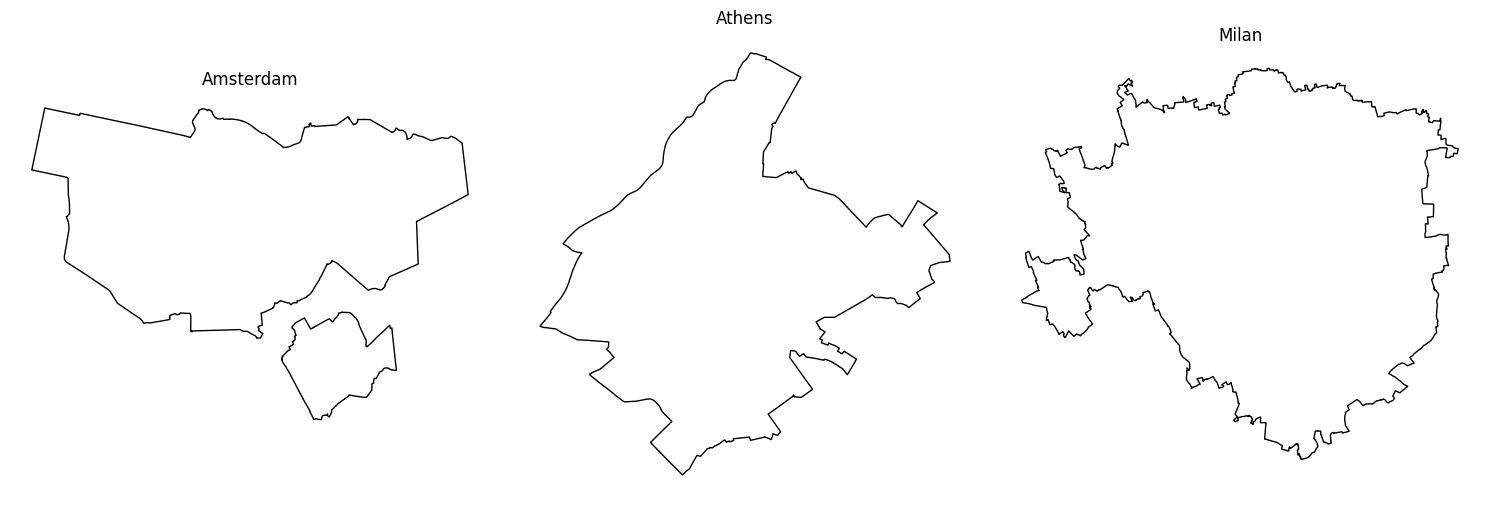

In [ ]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

gdfs = [gdf_ams, gdf_ath, gdf_mil]
titles = ["Amsterdam", "Athens", "Milan"]

for ax, gdf, title in zip(axes, gdfs, titles):
    gdf.plot(ax=ax, facecolor="none", edgecolor="black")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Make Hex Grid

In [3]:
ams_hex = acx.make_hex_grid(aoi=gdf_ams, resolution=9)    
ath_hex = acx.make_hex_grid(aoi=gdf_ath, resolution=9)    
mil_hex = acx.make_hex_grid(aoi=gdf_mil , resolution=9)    

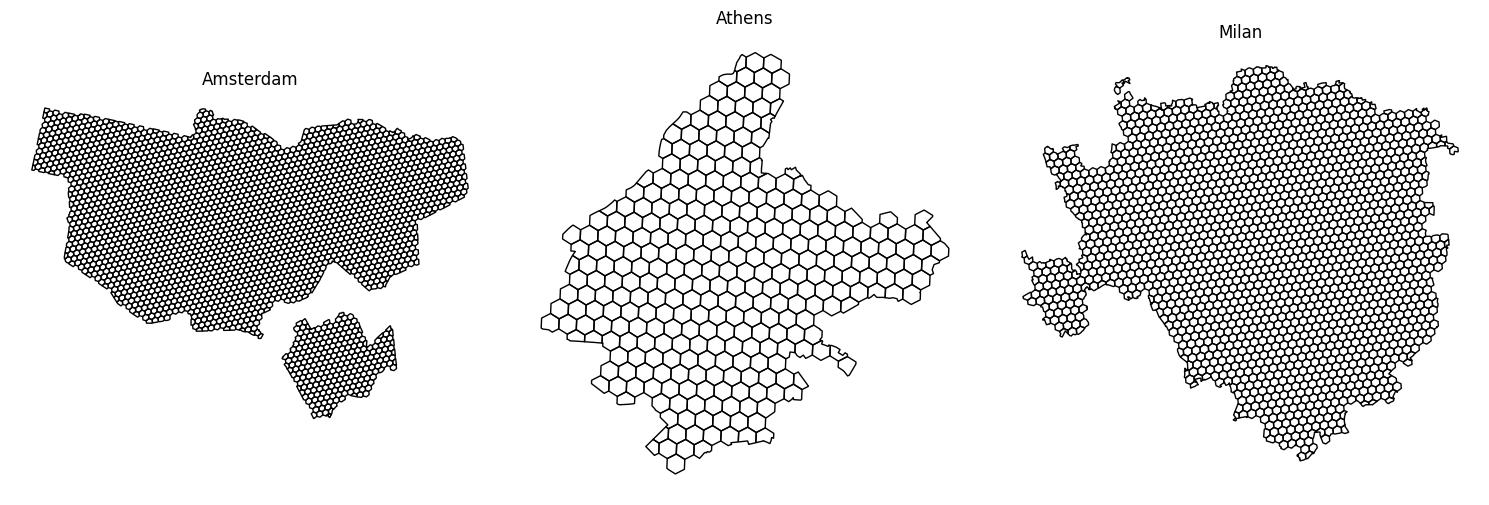

In [8]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

gdfs = [ams_hex, ath_hex, mil_hex]
titles = ["Amsterdam", "Athens", "Milan"]

for ax, gdf, title in zip(axes, gdfs, titles):
    gdf.plot(ax=ax, facecolor="none", edgecolor="black")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Download Street Network

In [ ]:
cities = [
    {"name": "amsterdam", "aoi": gdf_ams, "epsg": epsg_ams},
    {"name": "athens", "aoi": gdf_ath, "epsg": epsg_ath},
    {"name": "milan", "aoi": gdf_mil, "epsg": epsg_mil},
]

buffer = 1000
graphs = {}

for city in cities:
    G_proj = acx.build_network(
        AOI=city["aoi"],
        city_epsg=city["epsg"],
        buffer_m=buffer,
        network_type="walk",
        simplify=False,
        retain_all=True,
    )

    acx.save_graph(
        G_proj,
        out_dir=data_path + "/street_network/",
        base_name=f"original_graph_{city['name']}",
        save_nodes=True,
        save_edges=True,
    )
    graphs[city["name"]] = G_proj


### Add travel cost to the network
Add constant speed

In [19]:
# Read the graph 

cities = [
    {"name": "amsterdam", "epsg": epsg_ams},
    {"name": "athens", "epsg": epsg_ath},
    {"name": "milan", "epsg": epsg_mil},
]

graphs_with_speeds = {}

for city in cities:
    G_proj = acx.load_graph(
        nodes_path=data_path + f"/street_network/original_graph_{city['name']}_nodes_OSM.geojson",
        edges_path=data_path + f"/street_network/original_graph_{city['name']}_edges_OSM.geojson",
        crs=city["epsg"]
    )

    G_proj = acx.add_time_cost_constant_speed(
        G_proj,
        speed_kmh=4.5,
        cost_col="avg_time"
    )
    acx.save_graph(
        G_proj,
        out_dir=data_path + "/street_network/",
        base_name=f"graph_with_cost_{city['name']}",
        save_nodes=True,
        save_edges=True,
    )

    graphs_with_speeds[city["name"]] = G_proj


/Users/vmlias/repos/accessX/env_accessx/lib/python3.12/site-packages/osmnx/convert.py:302: UserWarning: Discarding the `gdf_nodes` 'geometry' column, though its values differ from the coordinates in the 'x' and 'y' columns.
  _validate_node_edge_gdfs(gdf_nodes, gdf_edges)
/Users/vmlias/repos/accessX/env_accessx/lib/python3.12/site-packages/osmnx/convert.py:302: UserWarning: Discarding the `gdf_nodes` 'geometry' column, though its values differ from the coordinates in the 'x' and 'y' columns.
  _validate_node_edge_gdfs(gdf_nodes, gdf_edges)
/Users/vmlias/repos/accessX/env_accessx/lib/python3.12/site-packages/osmnx/convert.py:302: UserWarning: Discarding the `gdf_nodes` 'geometry' column, though its values differ from the coordinates in the 'x' and 'y' columns.
  _validate_node_edge_gdfs(gdf_nodes, gdf_edges)


/Users/vmlias/repos/accessX/env_accessx/lib/python3.12/site-packages/osmnx/convert.py:302: UserWarning: Discarding the `gdf_nodes` 'geometry' column, though its values differ from the coordinates in the 'x' and 'y' columns.
  _validate_node_edge_gdfs(gdf_nodes, gdf_edges)


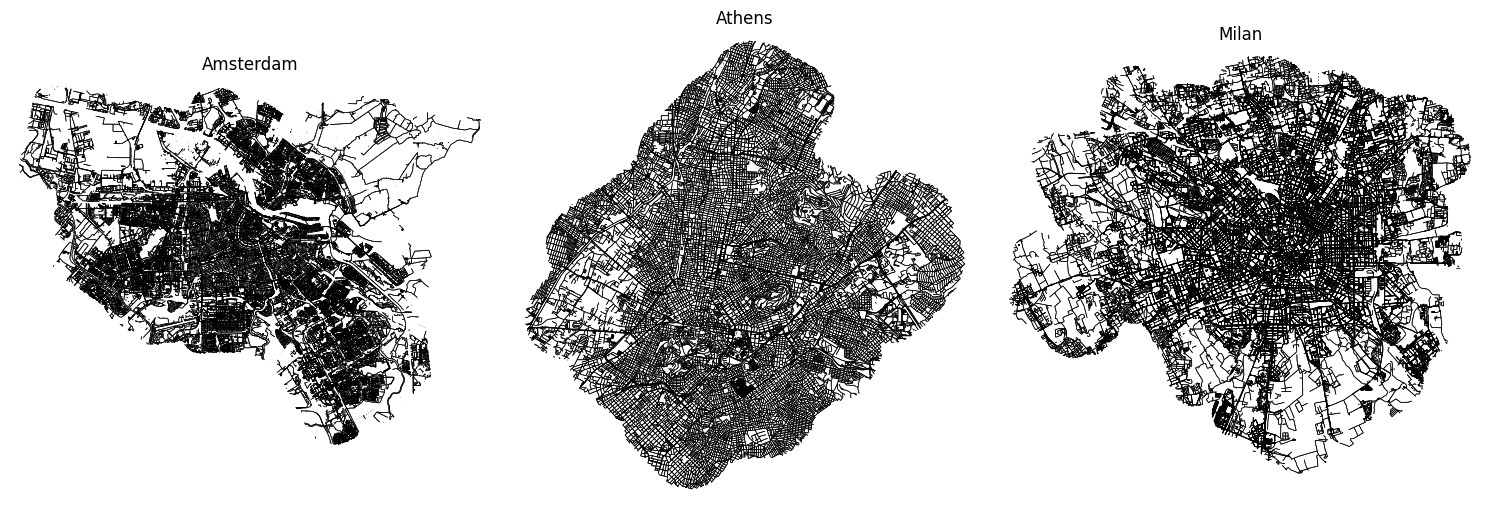

In [ ]:
graphs_with_speeds = {}

# read graphs
for city in cities:
    G_proj = acx.load_graph(
        nodes_path=data_path + f"/street_network/graph_with_cost_{city['name']}_nodes_OSM.geojson",
        edges_path=data_path + f"/street_network/graph_with_cost_{city['name']}_edges_OSM.geojson",
        crs=city["epsg"]
    )
    graphs_with_speeds[city["name"]] = G_proj

# plot graphs
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Amsterdam", "Athens", "Milan"]
city_names = ["amsterdam", "athens", "milan"]

for ax, city_name, title in zip(axes, city_names, titles):
    ox.plot_graph(
        graphs_with_speeds[city_name],
        ax=ax,
        node_size=0,
        edge_color="black",
        edge_linewidth=0.5,
        show=False,
        close=False
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Estimate Isochrones

In [34]:
gdfs_iso = {}

city_data = [
    {"name": "amsterdam", "hex": ams_hex, "epsg": epsg_ams},
    {"name": "athens", "hex": ath_hex, "epsg": epsg_ath},
    {"name": "milan", "hex": mil_hex, "epsg": epsg_mil},
]

for city in city_data:
    gdf_iso = acx.calculate_isochrones(
        graphs_with_speeds[city["name"]],
        city["hex"][:3].to_crs(city["epsg"]),
        max_cost=15,
        interval_size=5,
        cost_attr="avg_time",
        city_epsg=city["epsg"],
        max_distance=200,
        method="edges",
        n_jobs=os.cpu_count() - 1,
        edge_buff=25,
        infill=True,
        base_name=f"walksheds_{city['name']}",
        save_dir="data/walksheds/",
    )

    gdfs_iso[city["name"]] = gdf_iso

/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lamb

/var/folders/cb/4xmysnzx4v7gqv41_lr2kg200000gn/T/ipykernel_28886/10314364.py:15: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  gpd.GeoSeries(gdf["geom_avg_time_15"], crs=gdf.crs).dropna().plot(
/var/folders/cb/4xmysnzx4v7gqv41_lr2kg200000gn/T/ipykernel_28886/10314364.py:20: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  gpd.GeoSeries(gdf["geom_avg_time_10"], crs=gdf.crs).dropna().plot(
/var/folders/cb/4xmysnzx4v7gqv41_lr2kg200000gn/T/ipykernel_28886/10314364.py:25: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  gpd.GeoSeries(gdf["geom_avg_time_5"], crs=gdf.crs).dropna().plot(


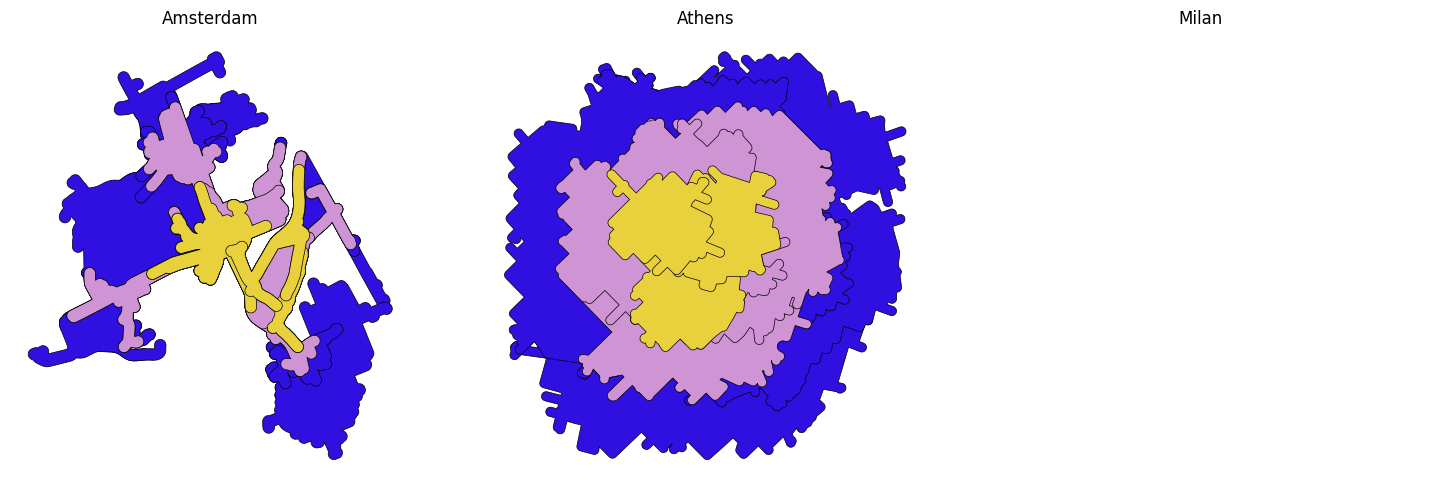

In [59]:
import matplotlib.pyplot as plt
import geopandas as gpd

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

titles = ["Amsterdam", "Athens", "Milan"]
city_names = ["amsterdam", "athens", "milan"]

city_names = ["amsterdam", "athens", "milan"]

for ax, city_name, title in zip(axes, city_names, titles):
    gdf = gdfs_iso[city_name]

    # 15 min in the back
    gpd.GeoSeries(gdf["geom_avg_time_15"], crs=gdf.crs).dropna().plot(
        ax=ax, color="#2f10e0", edgecolor="black", linewidth=0.5
    )

    # 10 min in the middle
    gpd.GeoSeries(gdf["geom_avg_time_10"], crs=gdf.crs).dropna().plot(
        ax=ax, color="#CE94D3", edgecolor="black", linewidth=0.5
    )

    # 5 min on top
    gpd.GeoSeries(gdf["geom_avg_time_5"], crs=gdf.crs).dropna().plot(
        ax=ax, color="#E8D13C", edgecolor="black", linewidth=0.5
    )

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [56]:
gdfs_iso["milan"]

,hex_id,geometry,geom_avg_time_5,geom_avg_time_10,geom_avg_time_15
0,891f995704bffff,"POLYGON ((515081.822 5025932.088, 515074.637 5...",None,None,None
1,891f995704fffff,"POLYGON ((515321.329 5026026.058, 515304.91 50...",None,None,None
2,891f9957043ffff,"POLYGON ((515104.978 5026493.775, 515272.072 5...",None,None,None
